In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohamedlkhalidi/recdataset/ratings.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/studentInfo.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/clicks.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/users.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/studentVle.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/courses.csv


In [2]:
import pandas as pd, glob, os

for f in glob.glob("/kaggle/input/datasets/mohamedlkhalidi/recdataset/*.csv", recursive=True):
    print("="*70)
    print(os.path.basename(f))
    d = pd.read_csv(f, nrows=5)
    print("Colonnes :", list(d.columns))
    print("Lignes (estimation) :", sum(1 for _ in open(f, encoding="latin1")) - 1)
    print(d.head(3).to_string())

ratings.csv
Colonnes : ['reviews', 'reviewers', 'date_reviews', 'rating', 'course_id', 'user_id']
Lignes (estimation) : 1501261
                                                                                                                                                                                                                                                                                                                                                      reviews  reviewers  date_reviews  rating                 course_id  user_id
0  Pretty dry, but I was able to pass with just two complete watches so I'm happy about that.  As usual there were some questions on the final exam that were NO WHERE in the course, which is annoying but far better than many microsoft tests I have taken.  Never found the suplimental material that the course references... but who cares... i passed!          0  Feb 12, 2020       4  google-cbrs-cpi-training        0
1                                   

In [3]:
import subprocess, sys, os

# Installer sentence-transformers pour les embeddings sémantiques
try:
    import sentence_transformers
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])

# Installer transformers pour GPT-2 (si vous voulez générer du contenu)
try:
    import transformers
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers"])

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device :", DEVICE)

# Hyperparamètres (comme dans le papier)
MAX_SEQ = 100        # longueur maximale de séquence
BATCH_SIZE = 32
EMBED_DIM = 100
HIDDEN_DIM = 100
EPOCHS = 30
LR = 1e-3
N_FOLDS = 5          # nombre de folds pour l'item cold-start

Device : cuda


In [5]:
# Charger les fichiers
ratings = pd.read_csv("/kaggle/input/datasets/mohamedlkhalidi/recdataset/ratings.csv")
courses = pd.read_csv("/kaggle/input/datasets/mohamedlkhalidi/recdataset/courses.csv")

print("ratings shape:", ratings.shape)
print("courses shape:", courses.shape)

# Fusion pour obtenir le nom du cours
df = ratings.merge(courses[['course_id', 'name']], on='course_id', how='left')
print("Colonnes après fusion:", df.columns.tolist())

# Nettoyage : supprimer les lignes sans nom de cours
df = df.dropna(subset=['name'])

# Binarisation de la note (seuil : rating >= 4 -> 1, sinon 0)
df['correct'] = (df['rating'] >= 4).astype(int)

# Trier par date (date_reviews) pour chaque utilisateur
df['date_reviews'] = pd.to_datetime(df['date_reviews'], errors='coerce')
df = df.sort_values(['user_id', 'date_reviews']).reset_index(drop=True)

print(f"Nombre d'interactions : {len(df)}")
print(f"Nombre d'utilisateurs : {df['user_id'].nunique()}")
print(f"Nombre de cours uniques : {df['course_id'].nunique()}")

ratings shape: (1454711, 6)
courses shape: (623, 4)
Colonnes après fusion: ['reviews', 'reviewers', 'date_reviews', 'rating', 'course_id', 'user_id', 'name']
Nombre d'interactions : 1454711
Nombre d'utilisateurs : 287808
Nombre de cours uniques : 604


In [6]:
# Mapping course_id -> index
course_ids = df['course_id'].unique()
course2idx = {c: i for i, c in enumerate(course_ids)}
df['course_idx'] = df['course_id'].map(course2idx)
N_COURSES = len(course_ids)
print("Nombre de cours :", N_COURSES)

# Grouper par utilisateur
seqs = []  # liste de tuples (skills, corrects)
users = []
for uid, g in df.groupby('user_id', sort=False):
    skills = g['course_idx'].values[-MAX_SEQ:]  # on garde les MAX_SEQ dernières
    corrects = g['correct'].values[-MAX_SEQ:]
    if len(skills) >= 3:   # garder les séquences d'au moins 3 interactions
        seqs.append((skills, corrects))
        users.append(uid)

print(f"Séquences conservées : {len(seqs)}")

Nombre de cours : 604
Séquences conservées : 262627


In [7]:
class KTDataset(Dataset):
    def __init__(self, sequences, max_seq=MAX_SEQ):
        self.seqs = sequences
        self.max_seq = max_seq

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        skills, corrects = self.seqs[idx]
        L = len(skills)
        x = np.zeros(self.max_seq, dtype=np.int64)   # input : combinaison skill+reponse
        q = np.zeros(self.max_seq, dtype=np.int64)   # skill à prédire
        y = np.zeros(self.max_seq, dtype=np.float32) # cible
        mask = np.zeros(self.max_seq, dtype=np.float32)
        pos = np.zeros(self.max_seq, dtype=np.int64)  # position (optionnel)

        # On décale : à l'instant t, on prédit la réponse sur q[t]
        for t in range(1, L):
            x[t-1] = skills[t-1] + corrects[t-1] * N_COURSES + 1   # encodage (2*N_COURSES+1)
            q[t-1] = skills[t]
            y[t-1] = corrects[t]
            mask[t-1] = 1.0
            pos[t-1] = t
        return x, q, y, mask, pos

train_dataset = KTDataset(seqs)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [8]:
# Modèle LSTM-M : embedding par identifiant (baseline sans contenu)
class LSTMM(nn.Module):
    def __init__(self, n_courses, embed_dim, hidden_dim):
        super().__init__()
        self.embed = nn.Embedding(2 * n_courses + 1, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, n_courses)

    def forward(self, x, q):
        # x : (batch, seq) indices des (skill+reponse)
        # q : (batch, seq) indices des skills cibles
        h, _ = self.lstm(self.embed(x))
        # on sélectionne la sortie correspondant au skill cible
        return torch.gather(self.out(h), 2, q.unsqueeze(-1)).squeeze(-1)

# Modèle EERNN-M avec contenu textuel (utilisation d'embeddings sémantiques)
class EERNN_M(nn.Module):
    def __init__(self, sem_matrix, embed_dim=100, hidden_dim=100):
        super().__init__()
        # sem_matrix : numpy array (n_courses, sem_dim)
        self.sem_dim = sem_matrix.shape[1]
        self.register_buffer("S", torch.tensor(sem_matrix, dtype=torch.float32))
        self.proj = nn.Linear(self.sem_dim, embed_dim)   # projection vers embed_dim
        self.lstm = nn.LSTM(2 * embed_dim, hidden_dim, batch_first=True)
        self.W1 = nn.Linear(2 * hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, 1)

    def item_emb(self, idx):
        # idx : (batch, seq) indices des cours
        return self.proj(self.S[idx])   # (batch, seq, embed_dim)

    def forward(self, x, r, q):
        # x : indices des cours passés (seq)
        # r : réponse à ces cours (0 ou 1, encodée comme 1 ou 2? on utilisera r=1 pour succès, 0 pour échec)
        # q : indices des cours cibles
        e = self.item_emb(x)                 # (batch, seq, embed_dim)
        # combiner avec la réponse : deux vecteurs pondérés
        r_onehot = (r == 1).float().unsqueeze(-1)   # shape (batch, seq, 1)
        xe = torch.cat([e * r_onehot, e * (1 - r_onehot)], dim=-1)  # (batch, seq, 2*embed_dim)
        h, _ = self.lstm(xe)                  # (batch, seq, hidden_dim)
        # prédiction pour q
        e_q = self.item_emb(q)                # (batch, seq, embed_dim)
        combined = torch.cat([h, e_q], dim=-1) # (batch, seq, hidden_dim+embed_dim)
        y = torch.relu(self.W1(combined))
        return self.W2(y).squeeze(-1)

In [9]:
from sentence_transformers import SentenceTransformer

# Charger un modèle de sentence embedding
st = SentenceTransformer("all-mpnet-base-v2", device=DEVICE)

# Récupérer les noms des cours dans l'ordre des indices
course_names = df[['course_id', 'name']].drop_duplicates('course_id').set_index('course_id')['name'].reindex(course_ids).fillna("").tolist()
print("Exemple de noms :", course_names[:5])

# Calculer les embeddings (normalisés)
S1 = st.encode(course_names, normalize_embeddings=True)
print("Embeddings S1 shape:", S1.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Exemple de noms : ['Child Nutrition and Cooking', 'Learning How to Learn: Powerful mental tools to help you master tough subjects', 'Strategic Management', 'Using Python to Access Web Data', 'Programming for Everybody (Getting Started with Python)']
Embeddings S1 shape: (604, 768)


In [10]:
def train_model(model, train_loader, epochs=EPOCHS, lr=LR, is_eernn=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.5)
    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batch in train_loader:
            if is_eernn:
                x, r, q, y, mask = batch
                x, r, q, y, mask = [t.to(DEVICE) for t in (x, r, q, y, mask)]
                pred = model(x, r, q)
            else:
                x, q, y, mask, _ = batch  # KTDataset retourne 5 éléments
                x, q, y, mask = x.to(DEVICE), q.to(DEVICE), y.to(DEVICE), mask.to(DEVICE)
                pred = model(x, q)
            loss = (loss_fn(pred, y) * mask).sum() / mask.sum()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
    return model

def evaluate_model(model, test_sequences, is_eernn=False):
    if is_eernn:
        test_dataset = EERNDataset(test_sequences)
    else:
        test_dataset = KTDataset(test_sequences)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
    model.eval()
    all_y, all_pred = [], []
    with torch.no_grad():
        for batch in test_loader:
            if is_eernn:
                x, r, q, y, mask = batch
                x, r, q, y, mask = [t.to(DEVICE) for t in (x, r, q, y, mask)]
                pred = torch.sigmoid(model(x, r, q))
            else:
                x, q, y, mask, _ = batch
                x, q, y, mask = x.to(DEVICE), q.to(DEVICE), y.to(DEVICE), mask.to(DEVICE)
                pred = torch.sigmoid(model(x, q))
            mask_bool = mask.bool()
            all_y.extend(y[mask_bool].cpu().numpy())
            all_pred.extend(pred[mask_bool].cpu().numpy())
    auc = roc_auc_score(all_y, all_pred) if len(set(all_y))>1 else 0.5
    return auc

In [11]:
class EERNDataset(Dataset):
    def __init__(self, sequences, max_seq=MAX_SEQ):
        self.seqs = sequences
        self.max_seq = max_seq

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        skills, corrects = self.seqs[idx]
        L = len(skills)
        x = np.zeros(self.max_seq, dtype=np.int64)   # cours passé
        r = np.zeros(self.max_seq, dtype=np.int64)   # réponse passée (0/1)
        q = np.zeros(self.max_seq, dtype=np.int64)   # cours courant
        y = np.zeros(self.max_seq, dtype=np.float32)
        mask = np.zeros(self.max_seq, dtype=np.float32)
        for t in range(1, L):
            x[t-1] = skills[t-1]
            r[t-1] = corrects[t-1]
            q[t-1] = skills[t]
            y[t-1] = corrects[t]
            mask[t-1] = 1.0
        return x, r, q, y, mask

In [12]:
def train_eernn(model, train_sequences, epochs=EPOCHS):
    train_dataset = EERNDataset(train_sequences)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.5)
    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for x, r, q, y, mask in train_loader:
            x, r, q, y, mask = x.to(DEVICE), r.to(DEVICE), q.to(DEVICE), y.to(DEVICE), mask.to(DEVICE)
            pred = model(x, r, q)
            loss = (loss_fn(pred, y) * mask).sum() / mask.sum()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
    return model

def evaluate_eernn(model, test_sequences):
    test_dataset = EERNDataset(test_sequences)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
    model.eval()
    all_y, all_pred = [], []
    with torch.no_grad():
        for x, r, q, y, mask in test_loader:
            x, r, q, y, mask = x.to(DEVICE), r.to(DEVICE), q.to(DEVICE), y.to(DEVICE), mask.to(DEVICE)
            pred = torch.sigmoid(model(x, r, q))
            mask_bool = mask.bool()
            all_y.extend(y[mask_bool].cpu().numpy())
            all_pred.extend(pred[mask_bool].cpu().numpy())
    auc = roc_auc_score(all_y, all_pred) if len(set(all_y))>1 else 0.5
    return auc

In [13]:
# Obtenir la liste des cours uniques (leurs ID originaux)
all_course_ids = list(course_ids)
np.random.seed(SEED)
np.random.shuffle(all_course_ids)
fold_size = len(all_course_ids) // N_FOLDS
course_folds_ids = [all_course_ids[i*fold_size:(i+1)*fold_size] for i in range(N_FOLDS)]

# Fonction pour obtenir les indices à partir des IDs
def get_indices_from_ids(ids_list):
    return {course2idx[cid] for cid in ids_list if cid in course2idx}

# Fonction de séparation (inchangée, mais utilise des indices)
def get_train_test_sequences(seqs, test_indices_set):
    train_seqs = []
    test_seqs = []
    for skills, corrects in seqs:
        if any(s in test_indices_set for s in skills):
            test_seqs.append((skills, corrects))
        else:
            train_seqs.append((skills, corrects))
    return train_seqs, test_seqs

# Stocker les résultats
results = {
    "fold": [],
    "LSTM-M AUC": [],
    "EERNN-M S1 AUC": [],
}

In [14]:
# Réinitialisation propre
results = {
    "fold": [],
    "LSTM-M AUC": [],
    "EERNN-M S1 AUC": []
}

for fold_idx, test_ids in enumerate(course_folds_ids):
    print(f"\n===== Fold {fold_idx+1}/{N_FOLDS} =====")
    test_indices = get_indices_from_ids(test_ids)
    train_seqs, test_seqs = get_train_test_sequences(seqs, test_indices)
    print(f"Train sequences: {len(train_seqs)}, Test sequences: {len(test_seqs)}")
    if len(test_seqs) == 0:
        print("Pas de séquences de test, skip")
        continue

    try:
        # ----- LSTM-M -----
        model_lstm = LSTMM(N_COURSES, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
        train_loader_lstm = DataLoader(KTDataset(train_seqs), batch_size=BATCH_SIZE, shuffle=True)
        train_model(model_lstm, train_loader_lstm, is_eernn=False)
        auc_lstm = evaluate_model(model_lstm, test_seqs, is_eernn=False)
        print(f"LSTM-M AUC: {auc_lstm:.4f}")

        # ----- EERNN-M S1 -----
        model_eernn_s1 = EERNN_M(S1, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
        train_eernn(model_eernn_s1, train_seqs)
        auc_s1 = evaluate_eernn(model_eernn_s1, test_seqs)
        print(f"EERNN-M S1 AUC: {auc_s1:.4f}")

        # Si on arrive ici, tout a réussi
        results["fold"].append(fold_idx+1)
        results["LSTM-M AUC"].append(auc_lstm)
        results["EERNN-M S1 AUC"].append(auc_s1)

    except Exception as e:
        print(f"Erreur sur le fold {fold_idx+1} : {e}")
        # Ne rien ajouter pour ce fold

# Vérification avant création du DataFrame
print("\nLongueurs des listes :", {k: len(v) for k, v in results.items()})

if len(results["fold"]) == 0:
    print("Aucun fold n'a réussi. Vérifiez les erreurs ci-dessus.")
else:
    results_df = pd.DataFrame(results)
    print("\n=== Résultats par fold ===")
    print(results_df.to_string(index=False))

    mean_lstm = np.mean(results["LSTM-M AUC"])
    std_lstm = np.std(results["LSTM-M AUC"])
    mean_s1 = np.mean(results["EERNN-M S1 AUC"])
    std_s1 = np.std(results["EERNN-M S1 AUC"])

    print("\n=== Résultats globaux ===")
    print(f"LSTM-M : {mean_lstm:.4f} ± {std_lstm:.4f}")
    print(f"EERNN-M S1 : {mean_s1:.4f} ± {std_s1:.4f}")

    results_df.to_csv("item_coldstart_results.csv", index=False)
    print("Résultats sauvegardés dans item_coldstart_results.csv")


===== Fold 1/5 =====
Train sequences: 186908, Test sequences: 75719
Epoch 10, Loss: 0.0124
Epoch 20, Loss: 0.0087
Epoch 30, Loss: 0.0079
LSTM-M AUC: 0.8275
Epoch 10, Loss: 0.0237
Epoch 20, Loss: 0.0198
Epoch 30, Loss: 0.0181
EERNN-M S1 AUC: 0.9601

===== Fold 2/5 =====
Train sequences: 181301, Test sequences: 81326
Epoch 10, Loss: 0.0118
Epoch 20, Loss: 0.0087
Epoch 30, Loss: 0.0080
LSTM-M AUC: 0.8424
Epoch 10, Loss: 0.0223
Epoch 20, Loss: 0.0184
Epoch 30, Loss: 0.0164
EERNN-M S1 AUC: 0.9571

===== Fold 3/5 =====
Train sequences: 197682, Test sequences: 64945
Epoch 10, Loss: 0.0137
Epoch 20, Loss: 0.0097
Epoch 30, Loss: 0.0087
LSTM-M AUC: 0.8433
Epoch 10, Loss: 0.0251
Epoch 20, Loss: 0.0210
Epoch 30, Loss: 0.0191
EERNN-M S1 AUC: 0.9628

===== Fold 4/5 =====
Train sequences: 203916, Test sequences: 58711
Epoch 10, Loss: 0.0141
Epoch 20, Loss: 0.0101
Epoch 30, Loss: 0.0092
LSTM-M AUC: 0.8553
Epoch 10, Loss: 0.0248
Epoch 20, Loss: 0.0211
Epoch 30, Loss: 0.0192
EERNN-M S1 AUC: 0.9630

===

In [15]:
# ============================================================
# PRODUCTION — EERNN-M entraîné sur TOUTES les séquences
#   Produit les artefacts nécessaires à la démo (inférence hors Kaggle)
# ============================================================
import json, torch, numpy as np, pandas as pd

# Entraînement final sur l'intégralité des séquences (aucun cours exclu)
model_item = EERNN_M(S1, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
train_eernn(model_item, seqs)

# 1) Poids du modèle
torch.save(model_item.state_dict(), "/kaggle/working/eernn_item.pt")

# 2) Matrice sémantique S1 (all-mpnet-base-v2) — évite de ré-encoder à la démo
np.save("/kaggle/working/S1_embeddings.npy", S1)

# 3) Mapping course_idx -> course_id + nom (nécessaire à l'inférence sur cours nouveaux)
pd.DataFrame({
    "course_idx":  list(range(N_COURSES)),
    "course_id":   list(course_ids),
    "course_name": course_names,
}).to_csv("/kaggle/working/course_mapping.csv", index=False)

# 4) Métadonnées + hyperparamètres (AUC tracée depuis results, non inventée)
auc_mean = float(np.nanmean(results["EERNN-M S1 AUC"]))
auc_std  = float(np.nanstd(results["EERNN-M S1 AUC"]))
meta_item = {
    "modele": "EERNN-M (contenu semantique all-mpnet-base-v2)",
    "role": "PRODUCTION cold-start item",
    "AUC_moyenne_5folds": auc_mean,
    "AUC_ecart_type": auc_std,
    "EMBED_DIM": EMBED_DIM,
    "HIDDEN_DIM": HIDDEN_DIM,
    "SEM_DIM": int(S1.shape[1]),
    "N_COURSES": int(N_COURSES),
    "MAX_SEQ": MAX_SEQ,
}
with open("/kaggle/working/eernn_item_meta.json", "w") as f:
    json.dump(meta_item, f, indent=2)

print("Artefacts sauvegardes :")
print("  - eernn_item.pt")
print("  - S1_embeddings.npy")
print("  - course_mapping.csv")
print("  - eernn_item_meta.json")
print(f"  AUC moyenne (5 folds) : {auc_mean:.4f} +/- {auc_std:.4f}")

Epoch 10, Loss: 0.0392
Epoch 20, Loss: 0.0343
Epoch 30, Loss: 0.0318
Artefacts sauvegardes :
  - eernn_item.pt
  - S1_embeddings.npy
  - course_mapping.csv
  - eernn_item_meta.json
  AUC moyenne (5 folds) : 0.9607 +/- 0.0021


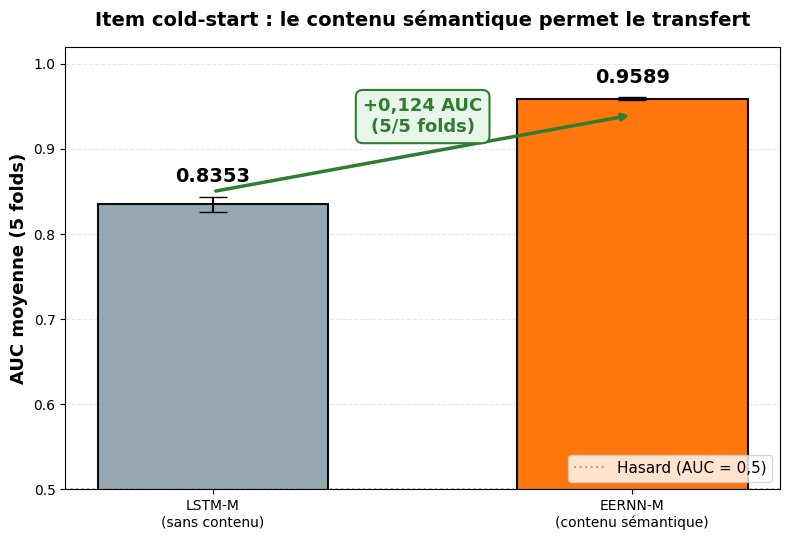

Figure 5.2 sauvegardée : fig_chap5_item_coursera.png


In [16]:
# ============================================================
# FIGURE 5.2 — Item cold-start : LSTM-M vs EERNN-M (bar chart)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Données vérifiées du run réel
models = ['LSTM-M\n(sans contenu)', 'EERNN-M\n(contenu sémantique)']
auc_means = [0.8353, 0.9589]
auc_stds  = [0.0088, 0.0016]
colors    = ['#90A4AE', '#FF6F00']

fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.bar(models, auc_means, yerr=auc_stds, capsize=10,
              color=colors, edgecolor='black', linewidth=1.5,
              width=0.55, alpha=0.95)

# Annotations des valeurs au-dessus des barres
for bar, val, std in zip(bars, auc_means, auc_stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + std + 0.012,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=14, fontweight='bold')

# Flèche du gain entre les deux barres
ax.annotate('', xy=(1, 0.94), xytext=(0, 0.85),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2.5))
ax.text(0.5, 0.92, '+0,124 AUC\n(5/5 folds)', ha='center',
        fontsize=13, fontweight='bold', color='#2E7D32',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9',
                  edgecolor='#2E7D32', linewidth=1.5))

# Lignes de référence
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.6,
           label='Hasard (AUC = 0,5)')

ax.set_ylim(0.5, 1.02)
ax.set_ylabel('AUC moyenne (5 folds)', fontsize=13, fontweight='bold')
ax.set_title("Item cold-start : le contenu sémantique permet le transfert",
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig_chap5_item_coursera.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 5.2 sauvegardée : fig_chap5_item_coursera.png")

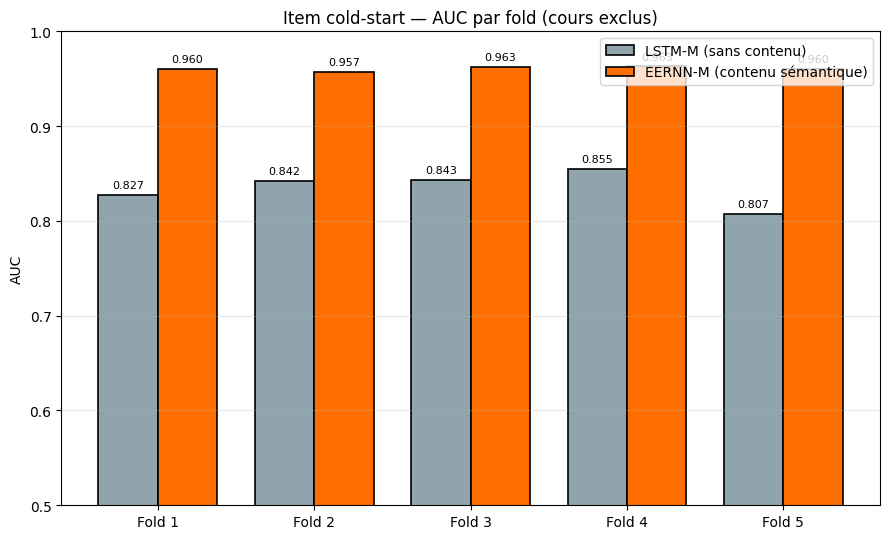

In [17]:
import matplotlib.pyplot as plt
import numpy as np

folds = results["fold"]
lstm  = np.array(results["LSTM-M AUC"])
eernn = np.array(results["EERNN-M S1 AUC"])
x = np.arange(len(folds)); w = 0.38

fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - w/2, lstm,  w, label='LSTM-M (sans contenu)',        color='#90A4AE', edgecolor='black', linewidth=1.2)
b2 = ax.bar(x + w/2, eernn, w, label='EERNN-M (contenu sémantique)', color='#FF6F00', edgecolor='black', linewidth=1.2)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'Fold {f}' for f in folds])
ax.set_ylabel('AUC'); ax.set_ylim(0.5, 1.0)
ax.set_title('Item cold-start — AUC par fold (cours exclus)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/fig_item_auc_par_fold.png', dpi=150, bbox_inches='tight'); plt.show()

/tmp/ipykernel_58/2469473446.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([lstm, eernn], labels=['LSTM-M', 'EERNN-M'],


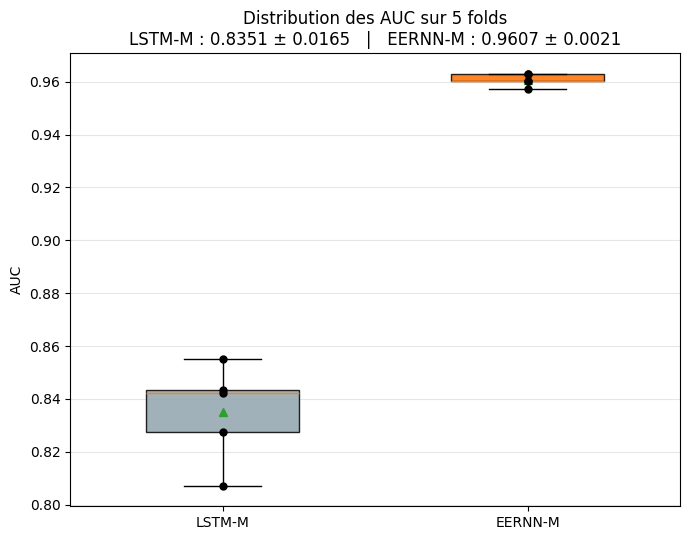

In [18]:
fig, ax = plt.subplots(figsize=(7, 5.5))
bp = ax.boxplot([lstm, eernn], labels=['LSTM-M', 'EERNN-M'],
                patch_artist=True, widths=0.5, showmeans=True)
for patch, color in zip(bp['boxes'], ['#90A4AE', '#FF6F00']):
    patch.set_facecolor(color); patch.set_alpha(0.85)
for i, data in enumerate([lstm, eernn], start=1):
    ax.scatter(np.full(len(data), i), data, color='black', zorder=3, s=25)
ax.set_ylabel('AUC')
ax.set_title(f'Distribution des AUC sur 5 folds\n'
             f'LSTM-M : {lstm.mean():.4f} ± {lstm.std():.4f}   |   '
             f'EERNN-M : {eernn.mean():.4f} ± {eernn.std():.4f}')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/fig_item_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

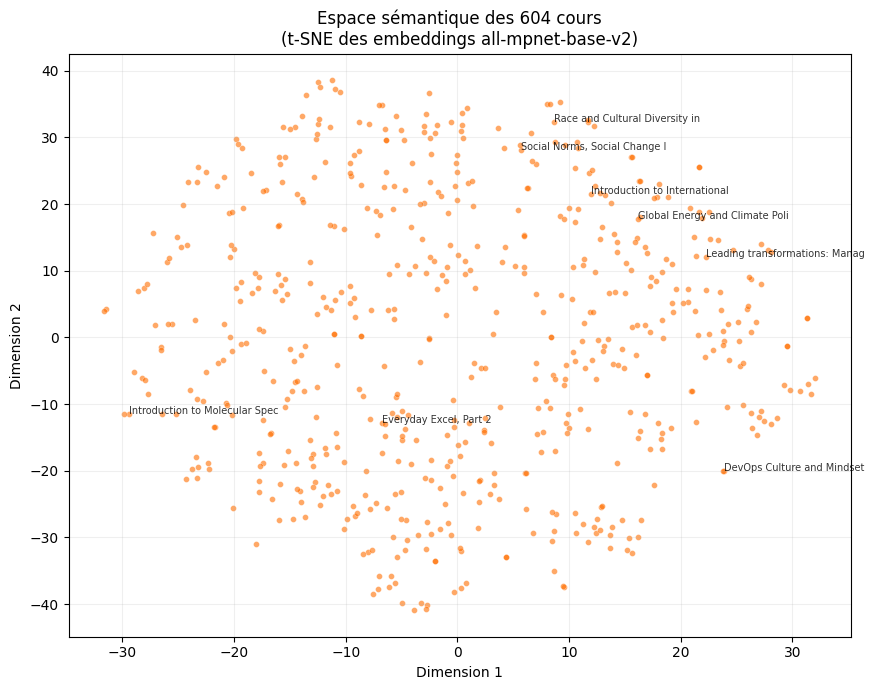

In [19]:
from sklearn.manifold import TSNE
import numpy as np, matplotlib.pyplot as plt

emb2d = TSNE(n_components=2, perplexity=30, random_state=SEED,
             init='pca', learning_rate='auto').fit_transform(np.asarray(S1))

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(emb2d[:,0], emb2d[:,1], s=18, color='#FF6F00',
           alpha=0.6, edgecolor='white', linewidth=0.3)

# annoter quelques cours pour la lisibilité
rng = np.random.default_rng(SEED)
for j in rng.choice(len(course_names), size=min(8, len(course_names)), replace=False):
    ax.annotate(str(course_names[j])[:30], (emb2d[j,0], emb2d[j,1]),
                fontsize=7, alpha=0.8)

ax.set_title(f'Espace sémantique des {len(S1)} cours\n(t-SNE des embeddings all-mpnet-base-v2)')
ax.set_xlabel('Dimension 1'); ax.set_ylabel('Dimension 2'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig('/kaggle/working/fig_item_tsne_cours.png', dpi=150, bbox_inches='tight'); plt.show()